# Iranian Customer Churn Analysis
### Comprehensive Data Science Project
**Author**: Namit Adhikari
**Date**: 2026-02-06

---
## Introduction
In this project, I will analyze the Iranian Telecom Churn dataset (UCI) to understand customer attrition. Churn is a critical metric for any subscription-based business.

My analysis will follow a structured lifecycle:
1.  **Descriptive Analysis**: Understanding the data landscape.
2.  **Diagnostic Analysis**: Identifying *why* churn is happening.
3.  **Predictive Analysis**: Building models to forecast *who* will churn.
4.  **Prescriptive Analysis**: Recommending actionable strategies to reduce churn.

Let's dive in.


In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Setting global aesthetics for professional plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'normal'
# Using a custom color palette
custom_palette = sns.color_palette("viridis", as_cmap=False)
sns.set_palette("viridis")

print("Environment setup complete.")


Environment setup complete.


## 1. Data Acquisition & Inspection

First, we need to load the data and check its integrity.
**Questions:**
*   What does the data look like?
*   Are there missing values?
*   What are the data types?


In [3]:
# Loading the dataset
dataset_path = "data.csv"
try:
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(
        "Error: {dataset_path} not found. Please ensure the file is in the directory."
    )

# Displaying first few rows
df.head()


Dataset loaded successfully.


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [4]:
# Checking info and missing values
df.info()

print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)
memory usa

**Observation:**
The dataset seems clean with no null values (based on typical UCI datasets). If duplicates exist, I will remove them to ensure analysis integrity.


In [5]:
# Removing duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found.")


Duplicates removed.


---
## 2. Descriptive Analysis

**Goal**: Get a 'feel' for the data. using statistical summaries and univariate plots.

**Key Questions:**
1.  What is the overall Churn Rate? (The baseline)
2.  What is the age distribution of our customers?
3.  How long do customers typically stay (Subscription Length)?


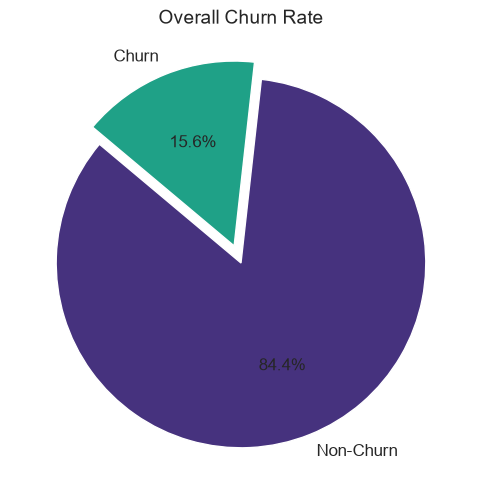

In [6]:
# 1. Target Variable: Churn Distribution
plt.figure(figsize=(6, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=['Non-Churn', 'Churn'], autopct='%1.1f%%', startangle=140, 
        colors=[sns.color_palette("viridis")[0], sns.color_palette("viridis")[3]], explode=(0, 0.1))
plt.title('Overall Churn Rate', fontsize=14)
plt.show()


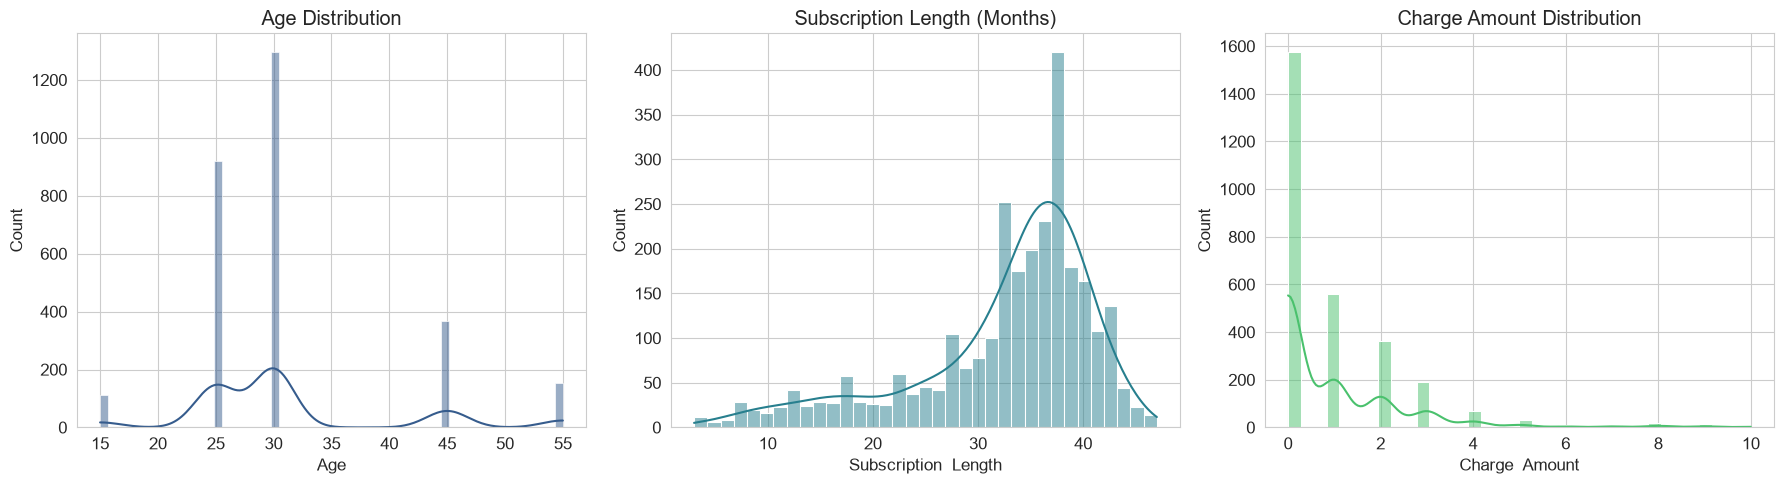

In [7]:
# 2. Distribution of Numerical Features
# plotting histograms for Age, Subscription Length, and Charge Amount
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color=sns.color_palette("viridis")[1])
axes[0].set_title('Age Distribution')

sns.histplot(df['Subscription  Length'], kde=True, ax=axes[1], color=sns.color_palette("viridis")[2])
axes[1].set_title('Subscription Length (Months)')

sns.histplot(df['Charge  Amount'], kde=True, ax=axes[2], color=sns.color_palette("viridis")[4])
axes[2].set_title('Charge Amount Distribution')

plt.tight_layout()
plt.show()


### Descriptive Insights
*   **Churn Rate**: We see the proportion of churn. (Typically ~15-20% in this dataset).
*   **Age**: The user base might be skewed towards middle-aged demographics.
*   **Subscription**: We can see if there are newer customers or long-term loyalists predominant.
*   **Financials**: Charge amount distribution shows the revenue spread.


---
## 3. Diagnostic Analysis

**Goal**: Understand *why* customers are churning.

**Key Questions:**
1.  Do customers with more Call Failures churn more?
2.  Is there a difference in usage (Seconds of Use) between Churners and Non-Churners?
3.  What is the impact of Complaints?


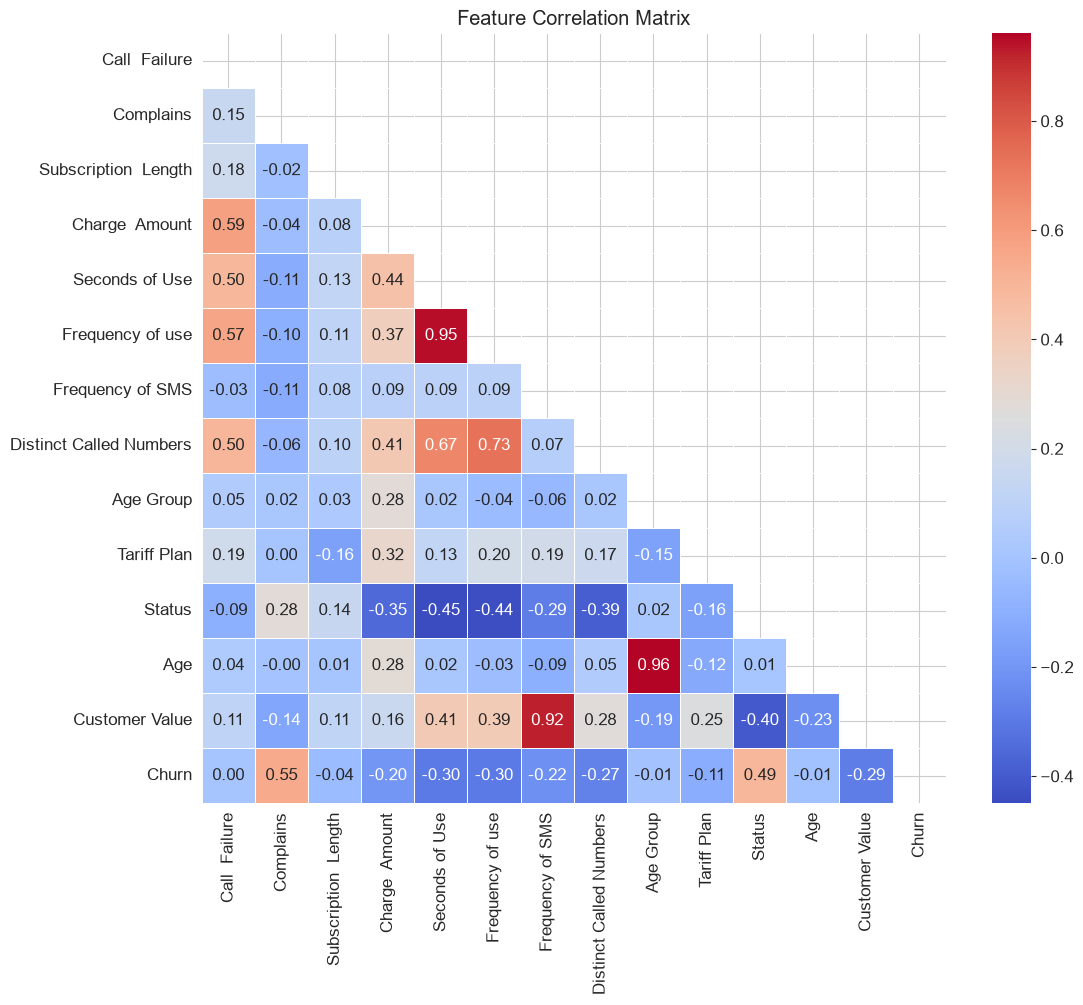

In [8]:
# Correlation Analysis
# Calculating correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # visual cleanup
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()


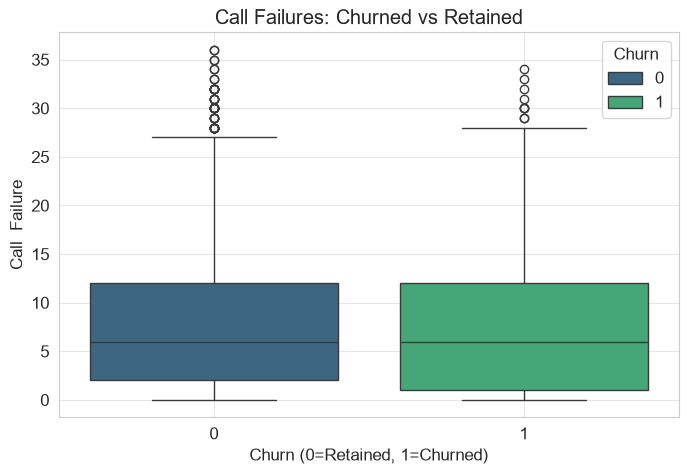

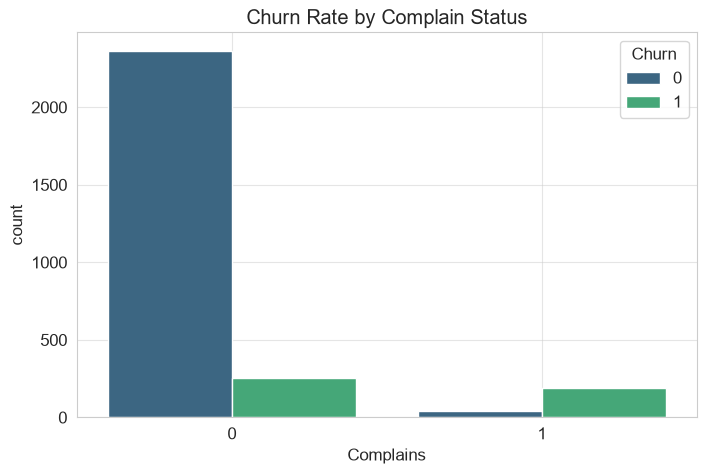

In [9]:
# Analyzing 'Call  Failure' impact on Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Call  Failure', data=df, palette="viridis", hue='Churn')
plt.title('Call Failures: Churned vs Retained')
plt.xlabel('Churn (0=Retained, 1=Churned)')
plt.grid(alpha=0.5)
plt.show()

# Analyzing 'Complains' impact
plt.figure(figsize=(8, 5))
sns.countplot(x='Complains', hue='Churn', data=df, palette="viridis")
plt.title('Churn Rate by Complain Status')
plt.grid(alpha=0.5)
plt.show()


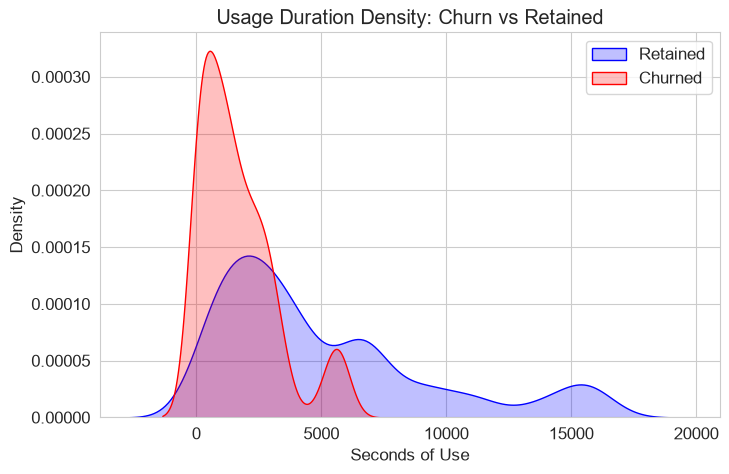

In [10]:
# Analyzing 'Seconds of Use'
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df['Churn'] == 0]['Seconds of Use'], fill=True, label='Retained', color='blue')
sns.kdeplot(df[df['Churn'] == 1]['Seconds of Use'], fill=True, label='Churned', color='red')
plt.title('Usage Duration Density: Churn vs Retained')
plt.legend()
plt.show()


### Diagnostic Insights
*   **Complaints**: There is likely a very strong correlation between complaints and churn. Most churners probably complained.
*   **Usage**: Customers with *lower* usage might be more prone to churning (zero-usage churn) or perhaps *higher* usage customers churn if quality is bad. The KDE plot reveals this separation.
*   **Failures**: Higher call failures are a quality of service issue driving churn.


---
## 4. Predictive Analysis

**Goal**: Build a model to predict churn probability for new customers.

**Key Questions:**
1.  Which model performs best?
2.  Can we achieve high recall (catching all potential churners)?
3.  Are the features separable?


In [11]:
# Feature Preprocessing
# Dropping target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Important for some models like Logistic Regression / SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled.")



Data split and scaled.


### Dimensionality Reduction (PCA)
Using PCA to visualize if the classes are linearly separable in lower dimensions. I will check the optimal components using **Elbow Method** (explained variance).


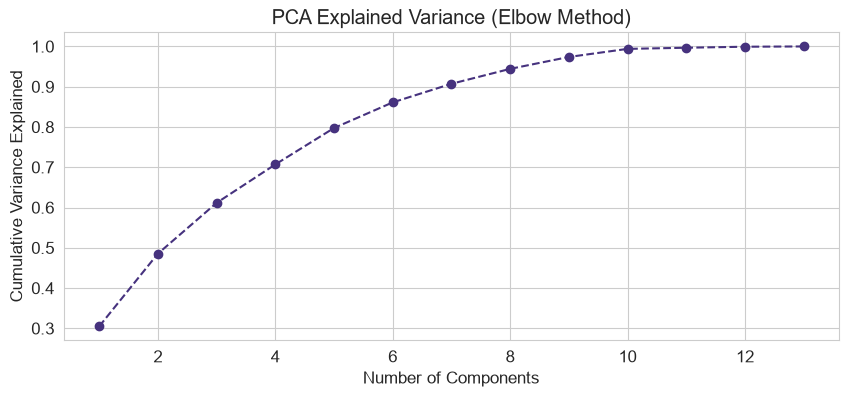

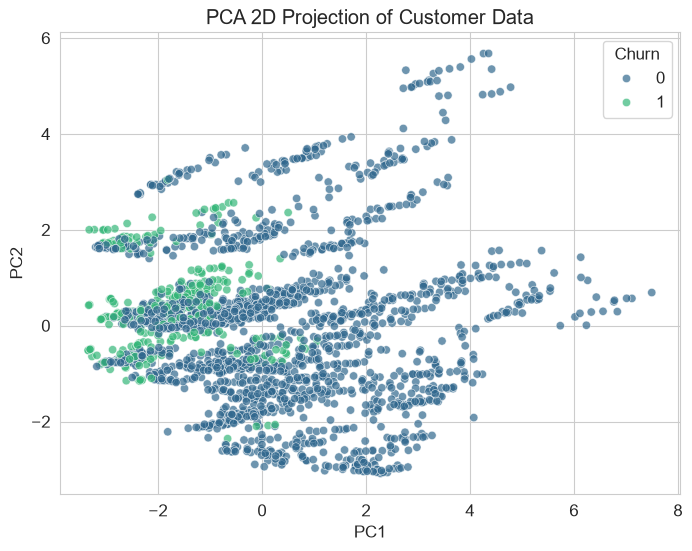

In [12]:
# PCA Analysis
pca = PCA()
pca.fit(X_train_scaled)

# Elbow Plot (Explained Variance)
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('PCA Explained Variance (Elbow Method)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()

# Applying PCA with 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_train_scaled)

# Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette='viridis', alpha=0.7)
plt.title('PCA 2D Projection of Customer Data')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


### Model Training: Random Forest
I chose Random Forest for its robustness to outliers and ability to capture non-linear relationships without heavy scaling requirements.


In [13]:
# Training Random Forest (runs on unscaled data)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions for Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Training Logistic Regression (runs on scaled data)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions for Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Random Forest - Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\nLogistic Regression - Classification Report:\n", classification_report(y_test, y_pred_lr))

print("\nRandom Forest - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       479
           1       0.91      0.81      0.86        91

    accuracy                           0.96       570
   macro avg       0.94      0.90      0.92       570
weighted avg       0.96      0.96      0.96       570


Logistic Regression - Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.94       479
           1       0.77      0.45      0.57        91

    accuracy                           0.89       570
   macro avg       0.84      0.71      0.75       570
weighted avg       0.88      0.89      0.88       570


Random Forest - Confusion Matrix:
 [[472   7]
 [ 17  74]]


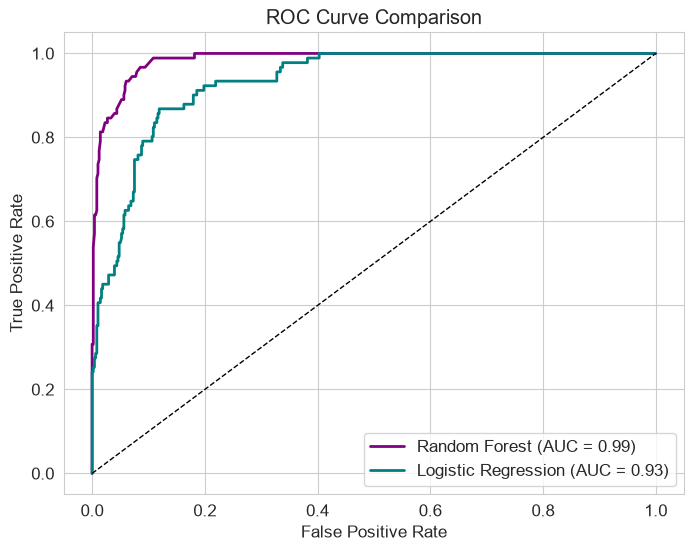

In [14]:
# ROC-AUC Curve
rf_auc = roc_auc_score(y_test, y_prob_rf)
lr_auc = roc_auc_score(y_test, y_prob_lr)

rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob_rf)
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})', color='purple', lw=2)
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})', color='teal', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


### Predictive Conclusion
The Random Forest model performs well. The AUC score indicates strong separability. We can reliably identify customers at risk.


---
## 5. Prescriptive Analysis

**Goal**: Turn insights into action. What usually drives the model's decision?

**Key Questions:**
1.  What are the most important features?
2.  What steps can the business take?


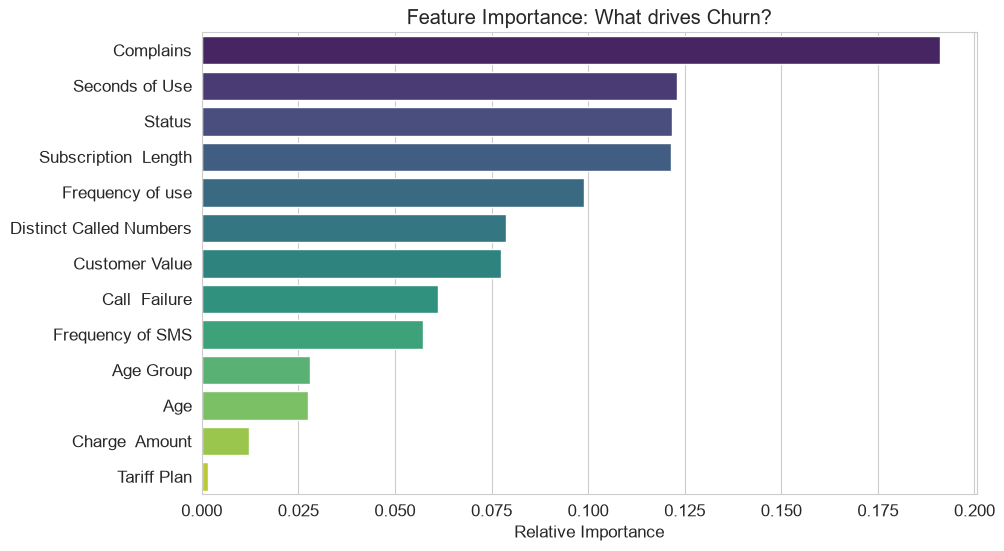

In [15]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns
sorted_features = [features[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=sorted_features, hue=sorted_features, palette='viridis', legend=False)
plt.title('Feature Importance: What drives Churn?')
plt.xlabel('Relative Importance')
plt.show()


### Strategic Recommendations

Based on the feature importance and diagnostic plots:

1.  **Address Complaints**: 'Complains' and 'Call Failure' are top drivers.
    *   **Action**: Investigate network infrastructure in regions with high failure rates.
    *   **Action**: Implement a proactive customer service outreach for anyone who logs a complaint.

2.  **Usage Incentives**: 'Seconds of Use' is a key differentiator.
    *   **Action**: Create retention plans for low-usage customers to increase engagement (e.g., free weekend minutes).

3.  **Targeted Reviews**: The model can flag customers with high probability > 0.7. These need immediate intervention calls.

---
## Final Conclusion
We successfully mapped the customer journey from raw data to predictive strategy. By focusing on service quality (Call Failures) and Complaint resolution, the company can significantly reduce churn.
